<a href="https://colab.research.google.com/github/nurahmi-tintyasusi-dev/data-science-2026/blob/main/Pertemuan7_Nurahmi_Tintyasusi_250401020035.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : NURAHMI TINTYASUSI

NIM : 250401020035

Kelas : IF401

Mata Kuliah : Data Science


---

Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


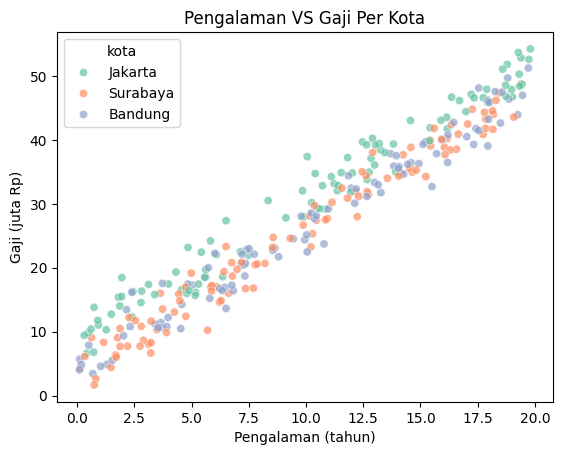

In [10]:
# Langkah 1: Generate dataset & EDA singkat

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

np.random.seed(42); n = 300
pengalaman = np.random.uniform(0, 20, n)
edu  = np.random.choice([0, 1, 2], n)              # SMA=0, D3=1, S1=2
kota = np.random.choice(['Jakarta','Surabaya','Bandung'], n)
gaji = (3.0 + 2.2*pengalaman + 1.5*edu
        + np.where(kota=='Jakarta', 4.0, 0)
        + np.random.normal(0, 2, n))

df = pd.DataFrame({'pengalaman':pengalaman, 'edu':edu,
                   'kota':kota, 'gaji':gaji})

# EDA Singkat

print('Shape:', df.shape)
print(df.describe().round(2))

#Scatter:Pengalaman VS Gaji

sns.scatterplot(data=df, x='pengalaman', y='gaji', hue='kota', palette='Set2', alpha=0.7)
plt.title('Pengalaman VS Gaji Per Kota')
plt.xlabel('Pengalaman (tahun)'); plt.ylabel('Gaji (juta Rp)')
plt.show()



In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Langkah 2a: One-Hot Encoding kolom 'kota'
df = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)
print('Kolom setelah encoding:', df.columns.tolist())
print()
print(df.head().round(2).to_string(index=False))




Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']

 pengalaman  edu  gaji  kota_Jakarta  kota_Surabaya
       7.49    0 21.95             1              0
      19.01    1 46.72             1              0
      14.64    2 34.95             0              1
      11.97    2 32.44             0              0
       3.12    2 17.38             1              0


In [12]:
# Langkah 2b: Pisah fitur & target, lalu train-test split
from sklearn.model_selection import train_test_split

X = df.drop('gaji', axis=1)
y = df['gaji']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')

Train: 240 baris, Test: 60 baris


In [13]:
# Langkah 2c: Feature Scaling - fit di TRAIN saja (anti data leakage)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # belajar mean & std dari train
X_test_s  = scaler.transform(X_test)        # hanya transform, TIDAK fit ulang
print('Scaling selesai: fit_transform di train, transform di test.')

Scaling selesai: fit_transform di train, transform di test.


In [14]:
# Langkah 3: Latih model & lihat koefisien
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_s, y_train)

print(f'β0 (intercept): {model.intercept_:.3f}')
print()
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))

# Interpretasi: fitur mana yang paling berpengaruh?
# Koefisien positif → gaji naik
# Koefisien negatif → gaji turun

β0 (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


In [52]:
# Langkah 4: Hitung MAE, RMSE, R2
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                          r2_score)
import numpy as np

y_pred = model.predict(X_test_s)

mae  = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE  = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R2   = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')

# Interpretasikan dalam Markdown sel berikutnya:
# - Berapa rata-rata kesalahan prediksi dalam rupiah?
# - Apakah R2 cukup baik untuk kasus ini?
# - Apakah ada indikasi outlier?

=== Metrik Evaluasi ===
MAE  = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R2   = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


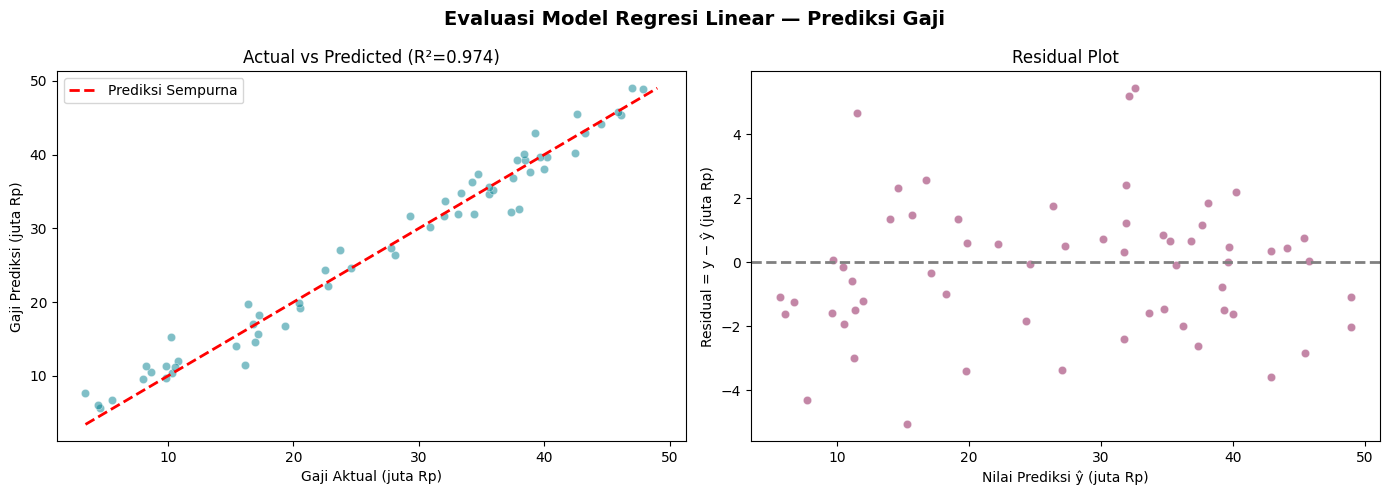

In [54]:

# Langkah 5: Actual vs Predicted & Residual Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#028090',
                edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted (R²={r2:.3f})')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='#880E4F',
                edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji',
             fontsize=14, fontweight='bold')
plt.savefig('evaluasi_regresi.png', dpi=300, bbox_inches='tight')
plt.tight_layout(); plt.show()

# Cara membaca Residual Plot:
# ✅ Baik: titik tersebar ACAK di sekitar garis y=0
# ❌ Masalah: ada pola (kurva, corong) → asumsi linearitas dilanggar

# KESIMPULAN

*  **Apa yang dipelajari:** Alur lengkap proses *machine learning* untuk regresi, mulai dari pembuatan data sintetis, Eksplorasi Data Analitik (EDA) menggunakan visualisasi scatterplot, hingga tahap preprocessing.
*  **Temuan Utama:** Melalui *Residual Plot*, titik-titik kesalahan tersebar secara acak di sekitar garis nol, menandakan asumsi linearitas model telah terpenuhi dengan baik dan tidak ada indikasi outlier yang mengganggu performa model (selisih RMSE dan MAE sangat kecil).
*  **Keterbatasan/Pertanyaan:** Dataset yang digunakan adalah data sintetis (buatan) yang polanya cenderung linier bersih dan minim noise. Pada dunia nyata, hubungan antara pengalaman, pendidikan, dan gaji seringkali bersifat non-linier dan memiliki banyak pencilan (*outliers*).